# Vanilla Options: Interactive Analysis & Visualizations

**Product Types:** European Vanilla Options | American Vanilla Options  
**Purpose:** Interactive exploration of option pricing, Greeks, and European vs American comparison

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Payoff Diagrams](#2-payoff-diagrams)
3. [Black-Scholes Price Surfaces](#3-black-scholes-price-surfaces)
4. [Greeks Analysis](#4-greeks-analysis)
5. [European vs American Comparison](#5-european-vs-american-comparison)
6. [Put-Call Parity](#6-put-call-parity)
7. [Early Exercise Analysis](#7-early-exercise-analysis)
8. [Implied Volatility](#8-implied-volatility)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# Color scheme
COLORS = {
    'call_long': '#2ecc71',    # Green
    'call_short': '#e74c3c',   # Red
    'put_long': '#3498db',     # Blue
    'put_short': '#f39c12',    # Orange
    'european': '#9b59b6',     # Purple
    'american': '#e67e22',     # Dark Orange
    'intrinsic': '#95a5a6',    # Gray
}

In [2]:
# Base parameters for analysis
BASE_PARAMS = {
    'S0': 100.0,      # Initial spot price
    'K': 100.0,       # Strike price (ATM)
    'T': 1.0,         # Time to maturity (1 year)
    'r': 0.05,        # Risk-free rate (5%)
    'q': 0.02,        # Dividend yield (2%)
    'sigma': 0.20,    # Volatility (20%)
}

print("Base Parameters:")
print("-" * 40)
for key, value in BASE_PARAMS.items():
    print(f"{key:12s}: {value}")

Base Parameters:
----------------------------------------
S0          : 100.0
K           : 100.0
T           : 1.0
r           : 0.05
q           : 0.02
sigma       : 0.2


## Pricing Functions

In [3]:
def d1(S, K, T, r, q, sigma):
    """Compute d1 parameter for Black-Scholes."""
    if T <= 0:
        return np.inf if S > K else -np.inf
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, q, sigma):
    """Compute d2 parameter for Black-Scholes."""
    return d1(S, K, T, r, q, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, q, sigma):
    """Black-Scholes European call option price."""
    if T <= 0:
        return max(S - K, 0)
    d1_val = d1(S, K, T, r, q, sigma)
    d2_val = d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.cdf(d1_val) - K * np.exp(-r * T) * norm.cdf(d2_val)

def bs_put(S, K, T, r, q, sigma):
    """Black-Scholes European put option price."""
    if T <= 0:
        return max(K - S, 0)
    d1_val = d1(S, K, T, r, q, sigma)
    d2_val = d2(S, K, T, r, q, sigma)
    return K * np.exp(-r * T) * norm.cdf(-d2_val) - S * np.exp(-q * T) * norm.cdf(-d1_val)

def american_binomial(S, K, T, r, q, sigma, N=200, option_type='put'):
    """
    American option price using CRR binomial tree.
    
    Parameters
    ----------
    N : int
        Number of time steps
    """
    if T <= 0:
        if option_type == 'call':
            return max(S - K, 0)
        return max(K - S, 0)
    
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp((r - q) * dt) - d) / (u - d)
    
    # Build price tree at maturity
    ST = S * u ** np.arange(N, -1, -1) * d ** np.arange(0, N + 1)
    
    # Terminal payoffs
    if option_type == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)
    
    # Backward induction with early exercise
    discount = np.exp(-r * dt)
    for i in range(N - 1, -1, -1):
        ST = S * u ** np.arange(i, -1, -1) * d ** np.arange(0, i + 1)
        V = discount * (p * V[:-1] + (1 - p) * V[1:])
        # Early exercise check
        if option_type == 'call':
            V = np.maximum(V, ST - K)
        else:
            V = np.maximum(V, K - ST)
    
    return V[0]

In [4]:
# Greeks functions
def bs_delta(S, K, T, r, q, sigma, option_type='call'):
    """Black-Scholes delta."""
    if T <= 0:
        if option_type == 'call':
            return 1.0 if S > K else 0.0
        return -1.0 if S < K else 0.0
    d1_val = d1(S, K, T, r, q, sigma)
    if option_type == 'call':
        return np.exp(-q * T) * norm.cdf(d1_val)
    return -np.exp(-q * T) * norm.cdf(-d1_val)

def bs_gamma(S, K, T, r, q, sigma):
    """Black-Scholes gamma (same for call and put)."""
    if T <= 0:
        return 0.0
    d1_val = d1(S, K, T, r, q, sigma)
    return np.exp(-q * T) * norm.pdf(d1_val) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, q, sigma):
    """Black-Scholes vega (same for call and put)."""
    if T <= 0:
        return 0.0
    d1_val = d1(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1_val)

def bs_theta(S, K, T, r, q, sigma, option_type='call'):
    """Black-Scholes theta (per year)."""
    if T <= 0:
        return 0.0
    d1_val = d1(S, K, T, r, q, sigma)
    d2_val = d2(S, K, T, r, q, sigma)
    
    term1 = -S * np.exp(-q * T) * norm.pdf(d1_val) * sigma / (2 * np.sqrt(T))
    if option_type == 'call':
        term2 = q * S * np.exp(-q * T) * norm.cdf(d1_val)
        term3 = -r * K * np.exp(-r * T) * norm.cdf(d2_val)
    else:
        term2 = -q * S * np.exp(-q * T) * norm.cdf(-d1_val)
        term3 = r * K * np.exp(-r * T) * norm.cdf(-d2_val)
    return term1 + term2 + term3

def bs_rho(S, K, T, r, q, sigma, option_type='call'):
    """Black-Scholes rho."""
    if T <= 0:
        return 0.0
    d2_val = d2(S, K, T, r, q, sigma)
    if option_type == 'call':
        return K * T * np.exp(-r * T) * norm.cdf(d2_val)
    return -K * T * np.exp(-r * T) * norm.cdf(-d2_val)

## 2. Payoff Diagrams

Visualizing the terminal payoff structure for vanilla options.

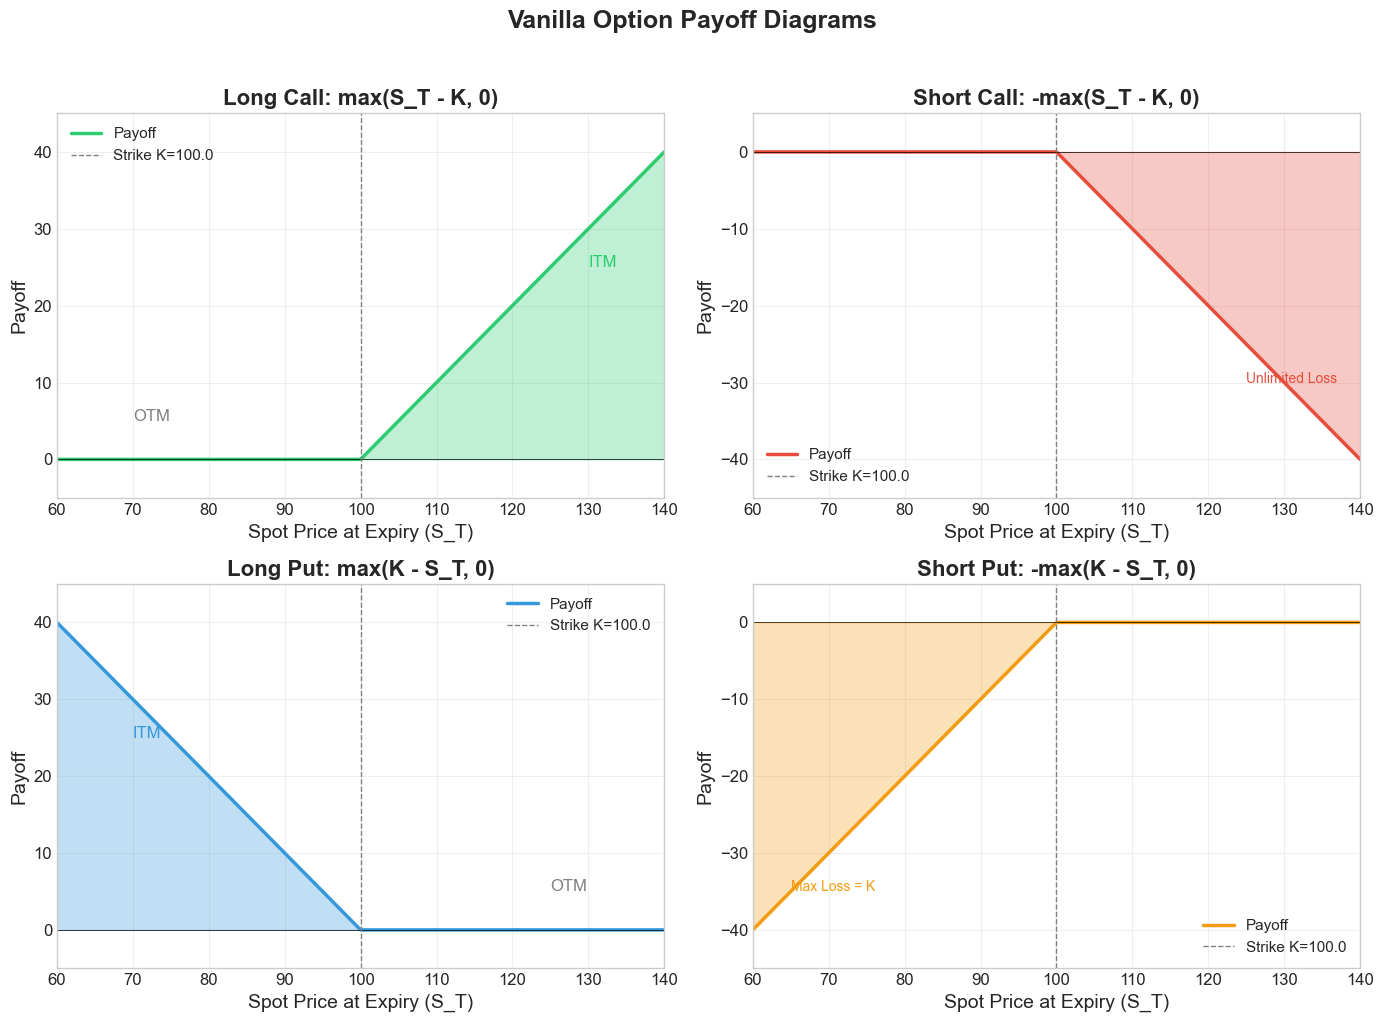

In [5]:
def plot_vanilla_payoff_diagrams(save_fig: bool = False):
    """
    Plot payoff diagrams for call and put options (long and short positions).
    """
    K = BASE_PARAMS['K']
    spots = np.linspace(60, 140, 500)
    
    # Payoffs
    call_payoff = np.maximum(spots - K, 0)
    put_payoff = np.maximum(K - spots, 0)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Long Call
    ax = axes[0, 0]
    ax.plot(spots, call_payoff, color=COLORS['call_long'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, call_payoff, alpha=0.3, color=COLORS['call_long'])
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Long Call: max(S_T - K, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-5, 45)
    ax.grid(True, alpha=0.3)
    ax.annotate('ITM', xy=(130, 25), fontsize=12, color=COLORS['call_long'])
    ax.annotate('OTM', xy=(70, 5), fontsize=12, color='gray')
    
    # Short Call
    ax = axes[0, 1]
    ax.plot(spots, -call_payoff, color=COLORS['call_short'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, -call_payoff, alpha=0.3, color=COLORS['call_short'])
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Short Call: -max(S_T - K, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-45, 5)
    ax.grid(True, alpha=0.3)
    ax.annotate('Unlimited Loss', xy=(125, -30), fontsize=10, color=COLORS['call_short'])
    
    # Long Put
    ax = axes[1, 0]
    ax.plot(spots, put_payoff, color=COLORS['put_long'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, put_payoff, alpha=0.3, color=COLORS['put_long'])
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Long Put: max(K - S_T, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-5, 45)
    ax.grid(True, alpha=0.3)
    ax.annotate('ITM', xy=(70, 25), fontsize=12, color=COLORS['put_long'])
    ax.annotate('OTM', xy=(125, 5), fontsize=12, color='gray')
    
    # Short Put
    ax = axes[1, 1]
    ax.plot(spots, -put_payoff, color=COLORS['put_short'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(spots, 0, -put_payoff, alpha=0.3, color=COLORS['put_short'])
    ax.set_xlabel('Spot Price at Expiry (S_T)')
    ax.set_ylabel('Payoff')
    ax.set_title('Short Put: -max(K - S_T, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-45, 5)
    ax.grid(True, alpha=0.3)
    ax.annotate('Max Loss = K', xy=(65, -35), fontsize=10, color=COLORS['put_short'])
    
    plt.suptitle('Vanilla Option Payoff Diagrams', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_payoff_diagrams.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_vanilla_payoff_diagrams(save_fig=False)

## 3. Black-Scholes Price Surfaces

3D visualization of option price as a function of spot and time/volatility.

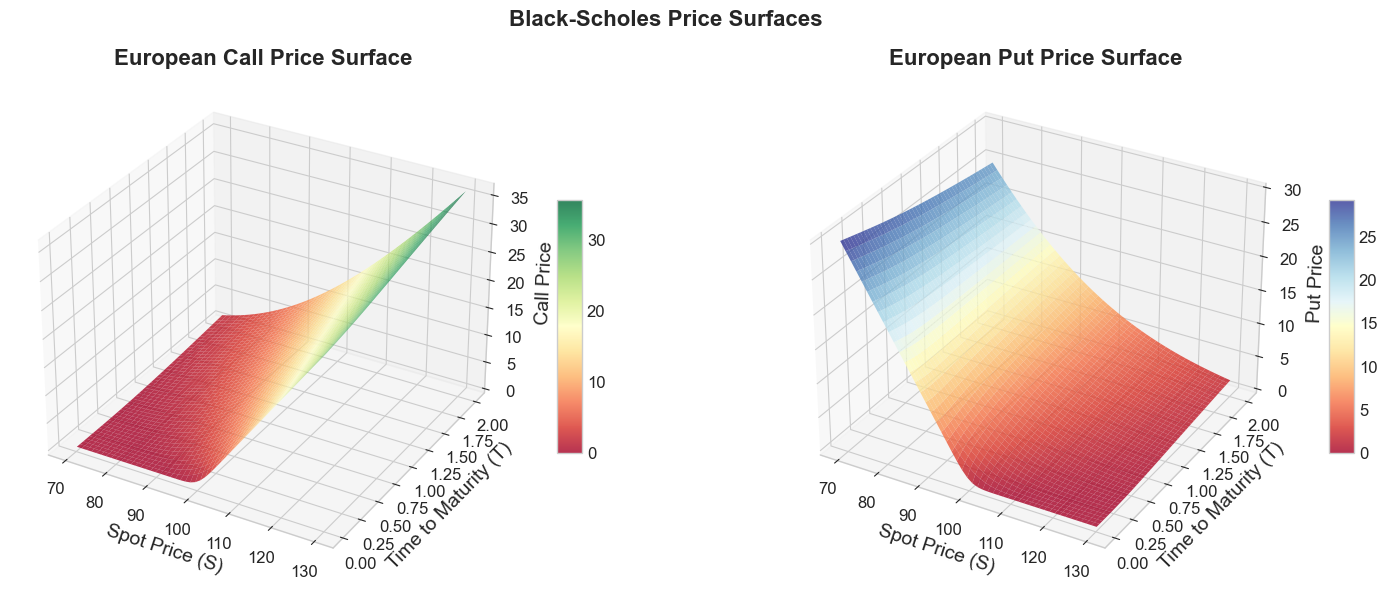

In [6]:
def plot_price_surface_spot_time(save_fig: bool = False):
    """
    Plot 3D price surface: Price vs Spot vs Time to Maturity.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(70, 130, 50)
    times = np.linspace(0.01, 2.0, 50)
    S_grid, T_grid = np.meshgrid(spots, times)
    
    call_prices = np.zeros_like(S_grid)
    put_prices = np.zeros_like(S_grid)
    
    for i in range(len(times)):
        for j in range(len(spots)):
            call_prices[i, j] = bs_call(spots[j], K, times[i], r, q, sigma)
            put_prices[i, j] = bs_put(spots[j], K, times[i], r, q, sigma)
    
    fig = plt.figure(figsize=(16, 6))
    
    # Call Surface
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(S_grid, T_grid, call_prices, cmap=cm.RdYlGn, alpha=0.8)
    ax1.set_xlabel('Spot Price (S)')
    ax1.set_ylabel('Time to Maturity (T)')
    ax1.set_zlabel('Call Price')
    ax1.set_title('European Call Price Surface', fontweight='bold')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    
    # Put Surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(S_grid, T_grid, put_prices, cmap=cm.RdYlBu, alpha=0.8)
    ax2.set_xlabel('Spot Price (S)')
    ax2.set_ylabel('Time to Maturity (T)')
    ax2.set_zlabel('Put Price')
    ax2.set_title('European Put Price Surface', fontweight='bold')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    plt.suptitle('Black-Scholes Price Surfaces', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_price_surface_time.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_surface_spot_time(save_fig=False)

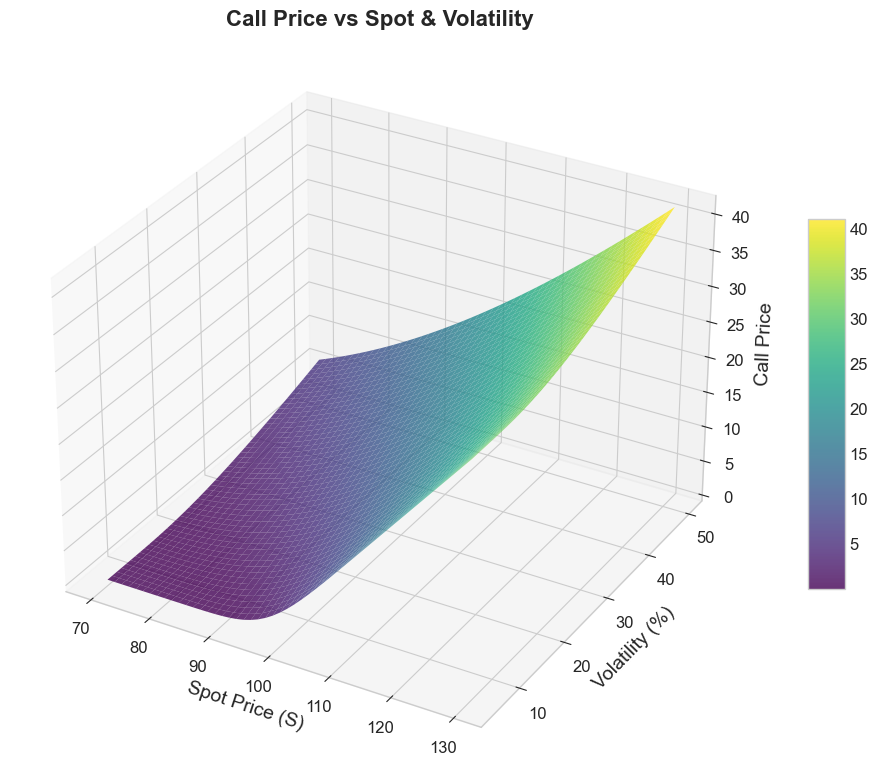

In [7]:
def plot_price_surface_spot_vol(save_fig: bool = False):
    """
    Plot 3D price surface: Price vs Spot vs Volatility.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    
    spots = np.linspace(70, 130, 50)
    vols = np.linspace(0.05, 0.50, 50)
    S_grid, V_grid = np.meshgrid(spots, vols)
    
    call_prices = np.zeros_like(S_grid)
    
    for i in range(len(vols)):
        for j in range(len(spots)):
            call_prices[i, j] = bs_call(spots[j], K, T, r, q, vols[i])
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(S_grid, V_grid * 100, call_prices, cmap=cm.viridis, alpha=0.8)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Volatility (%)')
    ax.set_zlabel('Call Price')
    ax.set_title('Call Price vs Spot & Volatility', fontweight='bold')
    fig.colorbar(surf, shrink=0.5, aspect=10)
    
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_price_surface_vol.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_surface_spot_vol(save_fig=False)

## 4. Greeks Analysis

Visualization of Delta, Gamma, Vega, Theta, and Rho.

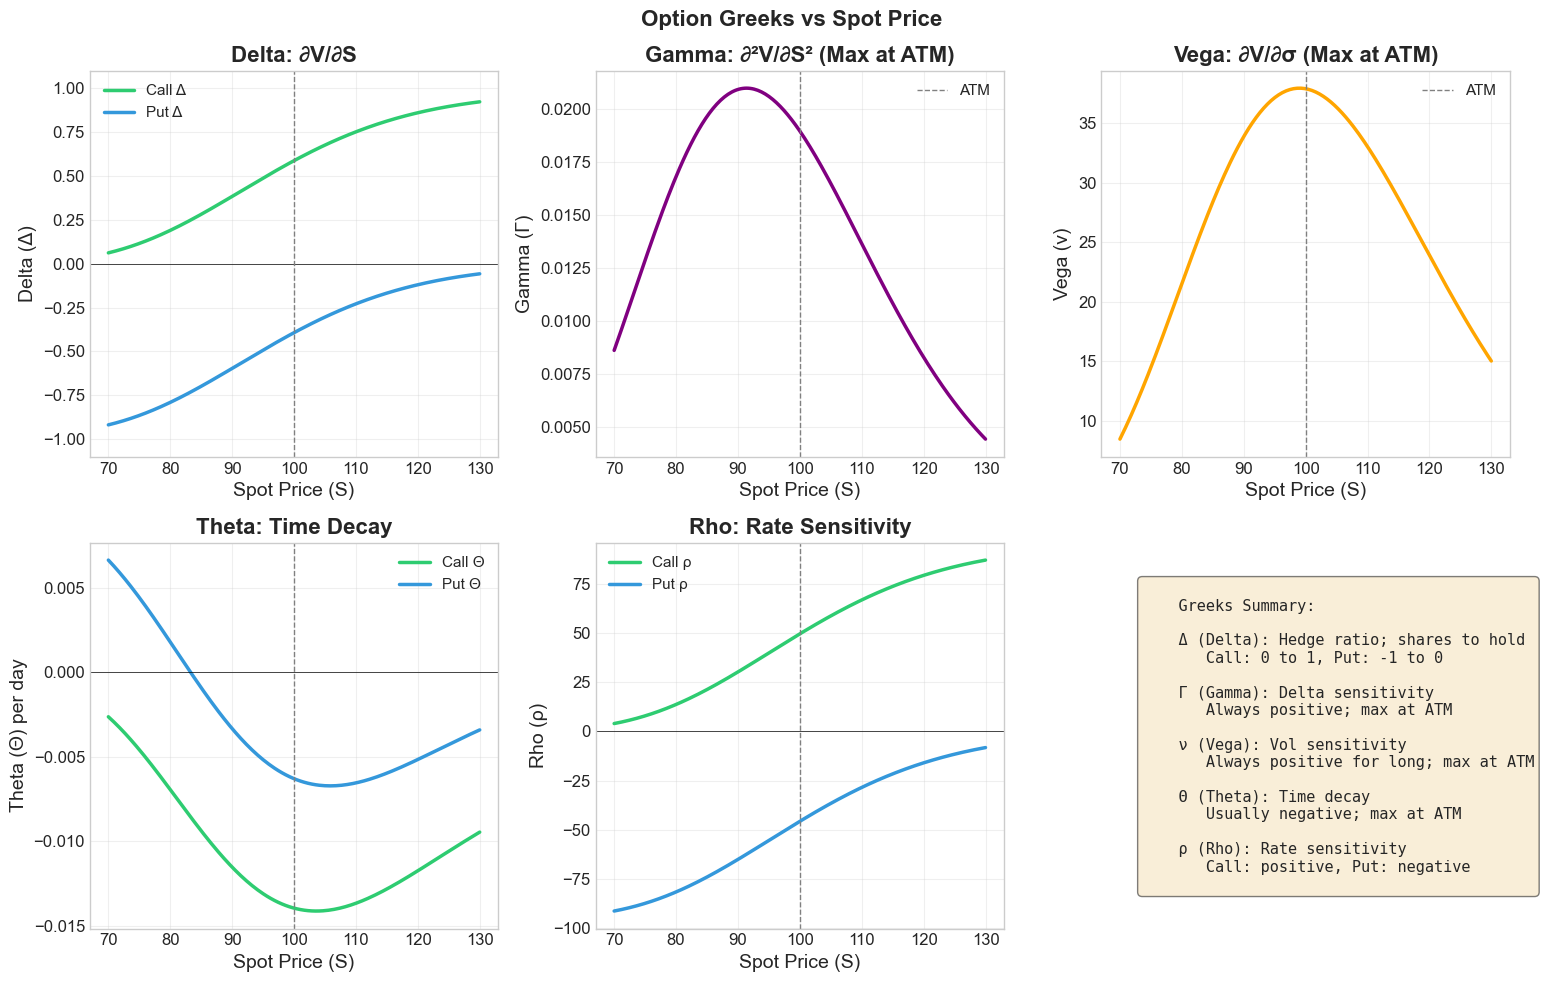

In [8]:
def plot_greeks_vs_spot(save_fig: bool = False):
    """
    Plot all Greeks as a function of spot price.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(70, 130, 200)
    
    # Compute Greeks for calls and puts
    call_delta = [bs_delta(S, K, T, r, q, sigma, 'call') for S in spots]
    put_delta = [bs_delta(S, K, T, r, q, sigma, 'put') for S in spots]
    gamma = [bs_gamma(S, K, T, r, q, sigma) for S in spots]
    vega = [bs_vega(S, K, T, r, q, sigma) for S in spots]
    call_theta = [bs_theta(S, K, T, r, q, sigma, 'call') / 365 for S in spots]  # Per day
    put_theta = [bs_theta(S, K, T, r, q, sigma, 'put') / 365 for S in spots]
    call_rho = [bs_rho(S, K, T, r, q, sigma, 'call') for S in spots]
    put_rho = [bs_rho(S, K, T, r, q, sigma, 'put') for S in spots]
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # Delta
    ax = axes[0, 0]
    ax.plot(spots, call_delta, color=COLORS['call_long'], linewidth=2.5, label='Call Δ')
    ax.plot(spots, put_delta, color=COLORS['put_long'], linewidth=2.5, label='Put Δ')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Delta (Δ)')
    ax.set_title('Delta: ∂V/∂S', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.1, 1.1)
    
    # Gamma
    ax = axes[0, 1]
    ax.plot(spots, gamma, color='purple', linewidth=2.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label='ATM')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Gamma (Γ)')
    ax.set_title('Gamma: ∂²V/∂S² (Max at ATM)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Vega
    ax = axes[0, 2]
    ax.plot(spots, vega, color='orange', linewidth=2.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label='ATM')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Vega (ν)')
    ax.set_title('Vega: ∂V/∂σ (Max at ATM)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Theta
    ax = axes[1, 0]
    ax.plot(spots, call_theta, color=COLORS['call_long'], linewidth=2.5, label='Call Θ')
    ax.plot(spots, put_theta, color=COLORS['put_long'], linewidth=2.5, label='Put Θ')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Theta (Θ) per day')
    ax.set_title('Theta: Time Decay', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rho
    ax = axes[1, 1]
    ax.plot(spots, call_rho, color=COLORS['call_long'], linewidth=2.5, label='Call ρ')
    ax.plot(spots, put_rho, color=COLORS['put_long'], linewidth=2.5, label='Put ρ')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Rho (ρ)')
    ax.set_title('Rho: Rate Sensitivity', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Summary text
    ax = axes[1, 2]
    ax.axis('off')
    summary = """
    Greeks Summary:
    
    Δ (Delta): Hedge ratio; shares to hold
       Call: 0 to 1, Put: -1 to 0
    
    Γ (Gamma): Delta sensitivity
       Always positive; max at ATM
    
    ν (Vega): Vol sensitivity
       Always positive for long; max at ATM
    
    Θ (Theta): Time decay
       Usually negative; max at ATM
    
    ρ (Rho): Rate sensitivity
       Call: positive, Put: negative
    """
    ax.text(0.1, 0.9, summary, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Option Greeks vs Spot Price', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_greeks.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_greeks_vs_spot(save_fig=False)

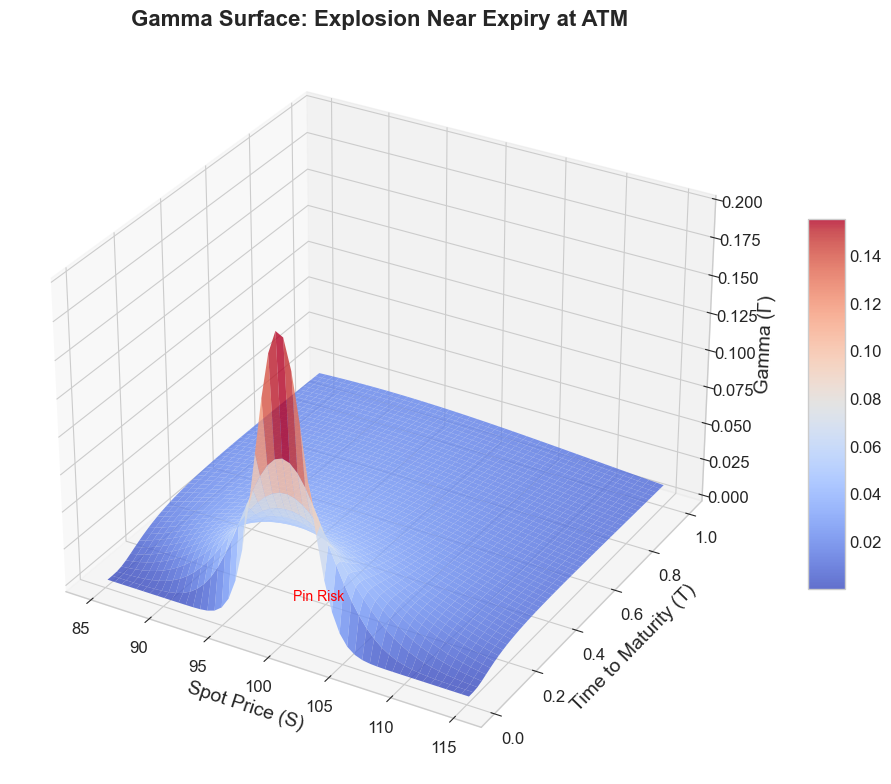

In [9]:
def plot_gamma_surface(save_fig: bool = False):
    """
    3D surface of Gamma vs Spot and Time (shows gamma explosion near expiry).
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(85, 115, 50)
    times = np.linspace(0.01, 1.0, 50)
    S_grid, T_grid = np.meshgrid(spots, times)
    
    gamma_surface = np.zeros_like(S_grid)
    for i in range(len(times)):
        for j in range(len(spots)):
            gamma_surface[i, j] = bs_gamma(spots[j], K, times[i], r, q, sigma)
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(S_grid, T_grid, gamma_surface, cmap=cm.coolwarm, alpha=0.8)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Time to Maturity (T)')
    ax.set_zlabel('Gamma (Γ)')
    ax.set_title('Gamma Surface: Explosion Near Expiry at ATM', fontweight='bold')
    fig.colorbar(surf, shrink=0.5, aspect=10)
    
    # Add annotation
    ax.text(100, 0.05, gamma_surface[-1, len(spots)//2], "Pin Risk", fontsize=10, color='red')
    
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_gamma_surface.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_gamma_surface(save_fig=False)

## 5. European vs American Comparison

Comparing European and American option prices to show early exercise premium.

Computing American option prices (binomial tree)...
Done!


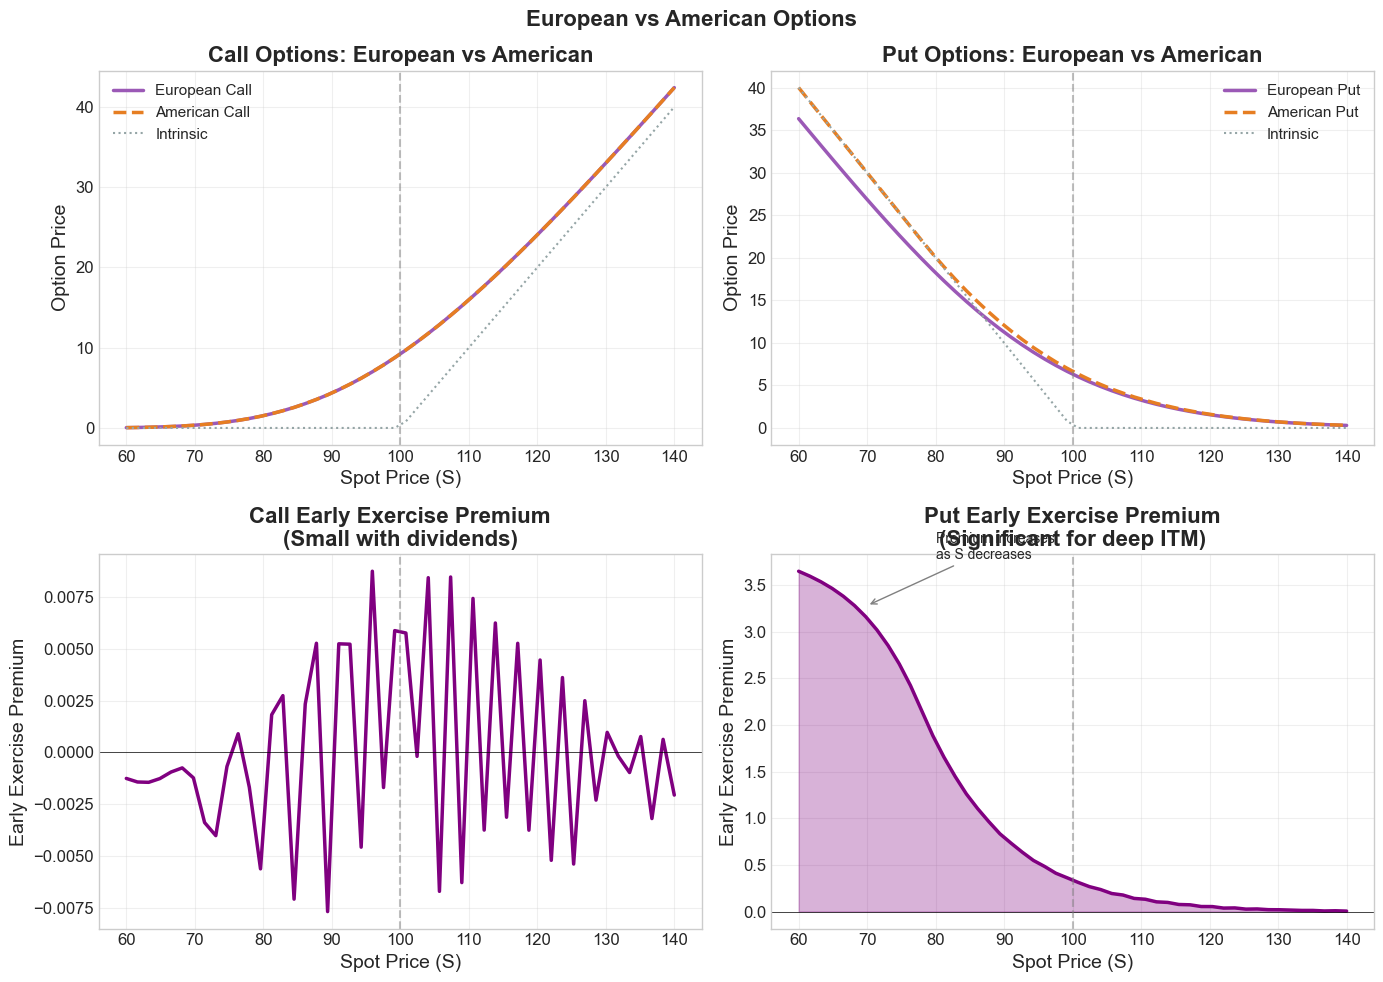

In [10]:
def plot_european_vs_american(save_fig: bool = False):
    """
    Compare European and American option prices.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(60, 140, 50)
    
    eur_calls = [bs_call(S, K, T, r, q, sigma) for S in spots]
    eur_puts = [bs_put(S, K, T, r, q, sigma) for S in spots]
    
    print("Computing American option prices (binomial tree)...")
    am_calls = [american_binomial(S, K, T, r, q, sigma, N=200, option_type='call') for S in spots]
    am_puts = [american_binomial(S, K, T, r, q, sigma, N=200, option_type='put') for S in spots]
    print("Done!")
    
    # Intrinsic values
    call_intrinsic = np.maximum(spots - K, 0)
    put_intrinsic = np.maximum(K - spots, 0)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Call comparison
    ax = axes[0, 0]
    ax.plot(spots, eur_calls, color=COLORS['european'], linewidth=2.5, label='European Call')
    ax.plot(spots, am_calls, color=COLORS['american'], linewidth=2.5, linestyle='--', label='American Call')
    ax.plot(spots, call_intrinsic, color=COLORS['intrinsic'], linewidth=1.5, linestyle=':', label='Intrinsic')
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Option Price')
    ax.set_title('Call Options: European vs American', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Put comparison
    ax = axes[0, 1]
    ax.plot(spots, eur_puts, color=COLORS['european'], linewidth=2.5, label='European Put')
    ax.plot(spots, am_puts, color=COLORS['american'], linewidth=2.5, linestyle='--', label='American Put')
    ax.plot(spots, put_intrinsic, color=COLORS['intrinsic'], linewidth=1.5, linestyle=':', label='Intrinsic')
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Option Price')
    ax.set_title('Put Options: European vs American', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Early exercise premium - Calls
    ax = axes[1, 0]
    call_premium = np.array(am_calls) - np.array(eur_calls)
    ax.plot(spots, call_premium, color='purple', linewidth=2.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Early Exercise Premium')
    ax.set_title('Call Early Exercise Premium\n(Small with dividends)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Early exercise premium - Puts
    ax = axes[1, 1]
    put_premium = np.array(am_puts) - np.array(eur_puts)
    ax.plot(spots, put_premium, color='purple', linewidth=2.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(spots, 0, put_premium, alpha=0.3, color='purple')
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Early Exercise Premium')
    ax.set_title('Put Early Exercise Premium\n(Significant for deep ITM)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.annotate('Premium increases\nas S decreases', xy=(70, put_premium[5]), 
                xytext=(80, put_premium[5] + 0.5), fontsize=10,
                arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.suptitle('European vs American Options', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_european_vs_american.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_european_vs_american(save_fig=False)

## 6. Put-Call Parity

Demonstrating the fundamental relationship between calls and puts.

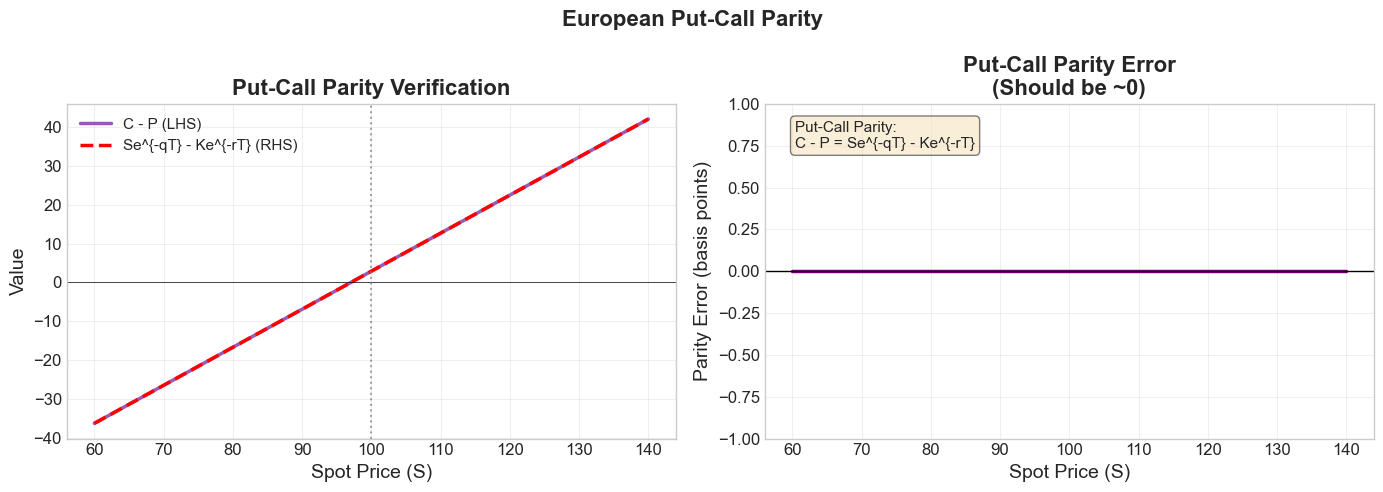

In [11]:
def plot_put_call_parity(save_fig: bool = False):
    """
    Demonstrate Put-Call Parity: C - P = S*e^(-qT) - K*e^(-rT)
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(60, 140, 100)
    
    calls = [bs_call(S, K, T, r, q, sigma) for S in spots]
    puts = [bs_put(S, K, T, r, q, sigma) for S in spots]
    
    # Put-Call Parity: C - P = S*e^(-qT) - K*e^(-rT)
    lhs = np.array(calls) - np.array(puts)  # C - P
    rhs = spots * np.exp(-q * T) - K * np.exp(-r * T)  # Forward - PV(K)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Parity demonstration
    ax = axes[0]
    ax.plot(spots, lhs, color=COLORS['european'], linewidth=2.5, label='C - P (LHS)')
    ax.plot(spots, rhs, color='red', linewidth=2.5, linestyle='--', label='Se^{-qT} - Ke^{-rT} (RHS)')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Value')
    ax.set_title('Put-Call Parity Verification', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Parity error (should be ~0)
    ax = axes[1]
    parity_error = lhs - rhs
    ax.plot(spots, parity_error * 10000, color='purple', linewidth=2.5)  # In basis points
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Parity Error (basis points)')
    ax.set_title('Put-Call Parity Error\n(Should be ~0)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1, 1)
    
    # Add formula
    textstr = 'Put-Call Parity:\nC - P = Se^{-qT} - Ke^{-rT}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('European Put-Call Parity', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_put_call_parity.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_put_call_parity(save_fig=False)

## 7. Early Exercise Analysis

Analyzing when early exercise is optimal for American options.

Computing early exercise boundaries (this may take a moment)...


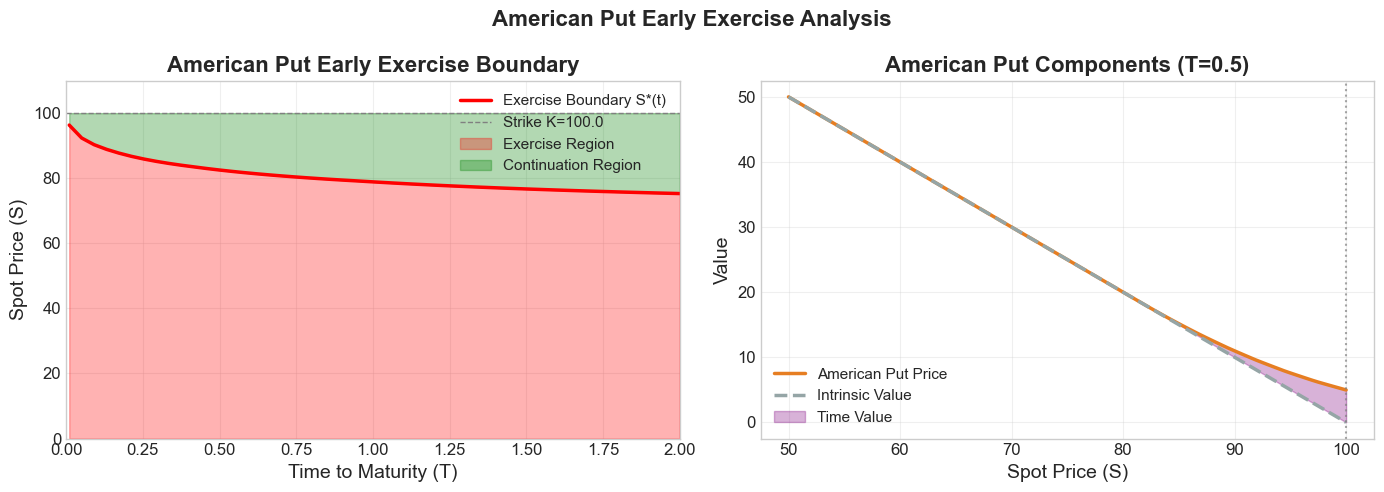

In [12]:
def plot_early_exercise_boundary(save_fig: bool = False):
    """
    Illustrate the early exercise boundary for American puts.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Estimate early exercise boundary at different times to maturity
    times = np.linspace(0.01, 2.0, 50)
    
    # For each time, find the spot where American put = intrinsic value
    # (approximation: where early exercise premium starts becoming significant)
    boundaries = []
    
    for T in times:
        # Binary search for the boundary
        S_low, S_high = 1, K
        for _ in range(50):
            S_mid = (S_low + S_high) / 2
            am_put = american_binomial(S_mid, K, T, r, q, sigma, N=100, option_type='put')
            intrinsic = max(K - S_mid, 0)
            
            # Check if we're at the boundary (American ≈ intrinsic)
            if am_put - intrinsic < 0.01:
                S_low = S_mid
            else:
                S_high = S_mid
        boundaries.append(S_mid)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Early exercise boundary
    ax = axes[0]
    ax.plot(times, boundaries, color='red', linewidth=2.5, label='Exercise Boundary S*(t)')
    ax.axhline(y=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(times, 0, boundaries, alpha=0.3, color='red', label='Exercise Region')
    ax.fill_between(times, boundaries, K, alpha=0.3, color='green', label='Continuation Region')
    ax.set_xlabel('Time to Maturity (T)')
    ax.set_ylabel('Spot Price (S)')
    ax.set_title('American Put Early Exercise Boundary', fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, K * 1.1)
    
    # Time value illustration
    ax = axes[1]
    S_range = np.linspace(50, 100, 100)
    T_fixed = 0.5
    
    am_puts = [american_binomial(S, K, T_fixed, r, q, sigma, N=100, option_type='put') for S in S_range]
    intrinsic = np.maximum(K - S_range, 0)
    time_value = np.array(am_puts) - intrinsic
    
    ax.plot(S_range, am_puts, color=COLORS['american'], linewidth=2.5, label='American Put Price')
    ax.plot(S_range, intrinsic, color=COLORS['intrinsic'], linewidth=2.5, linestyle='--', label='Intrinsic Value')
    ax.fill_between(S_range, intrinsic, am_puts, alpha=0.3, color='purple', label='Time Value')
    ax.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Value')
    ax.set_title(f'American Put Components (T={T_fixed})', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('American Put Early Exercise Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_early_exercise.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Computing early exercise boundaries (this may take a moment)...")
plot_early_exercise_boundary(save_fig=False)

## 8. Implied Volatility

Computing implied volatility from option prices.

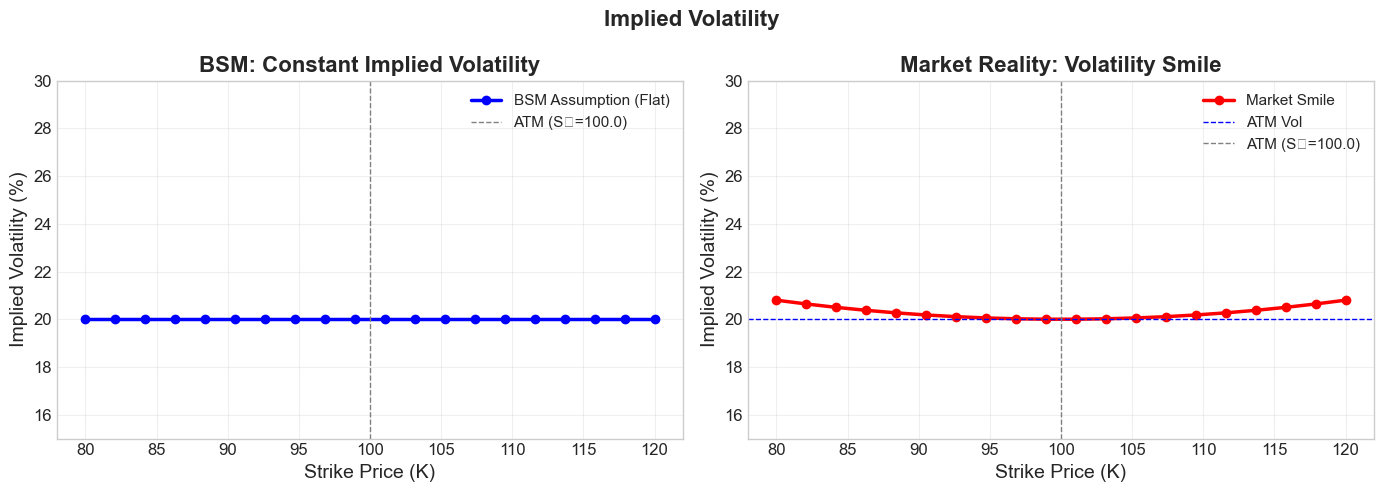

In [13]:
def implied_vol(price, S, K, T, r, q, option_type='call'):
    """
    Compute implied volatility using Brent's method.
    """
    def objective(sigma):
        if option_type == 'call':
            return bs_call(S, K, T, r, q, sigma) - price
        return bs_put(S, K, T, r, q, sigma) - price
    
    try:
        return brentq(objective, 0.001, 5.0)
    except:
        return np.nan

def plot_implied_vol_smile(save_fig: bool = False):
    """
    Generate and plot an implied volatility smile.
    """
    S0 = BASE_PARAMS['S0']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    true_sigma = BASE_PARAMS['sigma']
    
    # Generate strikes
    strikes = np.linspace(80, 120, 20)
    
    # Compute BSM prices
    call_prices = [bs_call(S0, K, T, r, q, true_sigma) for K in strikes]
    
    # Recover implied vols (should all be equal to true_sigma in BSM world)
    implied_vols = [implied_vol(p, S0, K, T, r, q, 'call') for p, K in zip(call_prices, strikes)]
    
    # Now let's create a "smile" by adding some skew to prices
    # (simulating real market behavior)
    skew_factor = 0.002 * (strikes - S0)**2 / S0  # Simple quadratic skew
    smile_vols = true_sigma + skew_factor
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Flat vol (BSM assumption)
    ax = axes[0]
    ax.plot(strikes, [true_sigma * 100] * len(strikes), color='blue', linewidth=2.5, 
            marker='o', markersize=6, label='BSM Assumption (Flat)')
    ax.axvline(x=S0, color='gray', linestyle='--', linewidth=1, label=f'ATM (S₀={S0})')
    ax.set_xlabel('Strike Price (K)')
    ax.set_ylabel('Implied Volatility (%)')
    ax.set_title('BSM: Constant Implied Volatility', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(15, 30)
    
    # Volatility smile (market reality)
    ax = axes[1]
    ax.plot(strikes, smile_vols * 100, color='red', linewidth=2.5, 
            marker='o', markersize=6, label='Market Smile')
    ax.axhline(y=true_sigma * 100, color='blue', linestyle='--', linewidth=1, label='ATM Vol')
    ax.axvline(x=S0, color='gray', linestyle='--', linewidth=1, label=f'ATM (S₀={S0})')
    ax.set_xlabel('Strike Price (K)')
    ax.set_ylabel('Implied Volatility (%)')
    ax.set_title('Market Reality: Volatility Smile', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(15, 30)
    
    plt.suptitle('Implied Volatility', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('vanilla_implied_vol.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_implied_vol_smile(save_fig=False)

## Summary Statistics

In [14]:
def print_summary_statistics():
    """
    Print comprehensive summary statistics.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Compute prices
    eur_call = bs_call(S0, K, T, r, q, sigma)
    eur_put = bs_put(S0, K, T, r, q, sigma)
    am_call = american_binomial(S0, K, T, r, q, sigma, option_type='call')
    am_put = american_binomial(S0, K, T, r, q, sigma, option_type='put')
    
    # Greeks (European)
    call_delta = bs_delta(S0, K, T, r, q, sigma, 'call')
    call_gamma = bs_gamma(S0, K, T, r, q, sigma)
    call_vega = bs_vega(S0, K, T, r, q, sigma)
    call_theta = bs_theta(S0, K, T, r, q, sigma, 'call')
    
    print("=" * 70)
    print("VANILLA OPTIONS: COMPREHENSIVE SUMMARY")
    print("=" * 70)
    print(f"\nBase Parameters: S₀={S0}, K={K}, T={T}, r={r*100:.1f}%, q={q*100:.1f}%, σ={sigma*100:.0f}%")
    
    print("\n" + "-" * 70)
    print("OPTION PRICES")
    print("-" * 70)
    print(f"{'Type':<25} {'Call':>15} {'Put':>15}")
    print("-" * 70)
    print(f"{'European (BSM)':<25} {eur_call:>15.4f} {eur_put:>15.4f}")
    print(f"{'American (Binomial)':<25} {am_call:>15.4f} {am_put:>15.4f}")
    print(f"{'Early Exercise Premium':<25} {am_call - eur_call:>15.4f} {am_put - eur_put:>15.4f}")
    
    print("\n" + "-" * 70)
    print("PUT-CALL PARITY CHECK")
    print("-" * 70)
    parity_lhs = eur_call - eur_put
    parity_rhs = S0 * np.exp(-q * T) - K * np.exp(-r * T)
    print(f"C - P = {parity_lhs:.4f}")
    print(f"Se^(-qT) - Ke^(-rT) = {parity_rhs:.4f}")
    print(f"Parity Error = {abs(parity_lhs - parity_rhs):.2e}")
    
    print("\n" + "-" * 70)
    print("GREEKS (EUROPEAN CALL)")
    print("-" * 70)
    print(f"Delta (Δ):  {call_delta:>10.4f}  (shares to hold per option)")
    print(f"Gamma (Γ):  {call_gamma:>10.4f}  (delta sensitivity)")
    print(f"Vega (ν):   {call_vega:>10.4f}  (per 1% vol change)")
    print(f"Theta (Θ):  {call_theta/365:>10.4f}  (per day)")
    
    print("\n" + "-" * 70)
    print("KEY RELATIONSHIPS")
    print("-" * 70)
    print(f"d₁ = {d1(S0, K, T, r, q, sigma):.4f}")
    print(f"d₂ = {d2(S0, K, T, r, q, sigma):.4f}")
    print(f"N(d₂) = {norm.cdf(d2(S0, K, T, r, q, sigma)):.4f} (Prob ITM)")
    print("=" * 70)

print_summary_statistics()

VANILLA OPTIONS: COMPREHENSIVE SUMMARY

Base Parameters: S₀=100.0, K=100.0, T=1.0, r=5.0%, q=2.0%, σ=20%

----------------------------------------------------------------------
OPTION PRICES
----------------------------------------------------------------------
Type                                 Call             Put
----------------------------------------------------------------------
European (BSM)                     9.2270          6.3301
American (Binomial)                9.2173          6.6560
Early Exercise Premium            -0.0097          0.3259

----------------------------------------------------------------------
PUT-CALL PARITY CHECK
----------------------------------------------------------------------
C - P = 2.8969
Se^(-qT) - Ke^(-rT) = 2.8969
Parity Error = 0.00e+00

----------------------------------------------------------------------
GREEKS (EUROPEAN CALL)
----------------------------------------------------------------------
Delta (Δ):      0.5869  (shares to h